<a href="https://colab.research.google.com/github/PabloCastroMontes/PAS_PE2526/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# El núcleo: implementar una función para simular el PAS
Definimos una función `simular_PAS()` que reciba tres argumentos:

*   p : este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería 1-p). Es un valor entre 0 y 1.
*   n : el número de pasos a simular para cada trayectoria. Un número natural.

*   reps : el número de trayectorias a simular. Un número natural.

La función devuelve un array de numpy con dimensionalidad `(reps, n)`, que contiene los valores del PAS en cada paso para cada trayectoria.

In [2]:
def simular_PAS(p,n,reps=1):
  # p : probabilidad tomar el valor 1 en cada paso (un valor entre 0 y 1)
  # n : numero de pasos a simular de cada trayectoria (un numero natural)
  # reps : numero de trayectorias a simular (un numero natural)

  Z = np.random.choice([-1,1], size=(reps,n), p=[1-p,p]) # matriz de dimensionalidad (reps, n) que contiene los Zt que definien el PAS de cada trayectoria
  trayectorias_pas = np.cumsum(Z, axis=1) # matriz de dimensionalidad (reps, n) cuyas filas son cada trayectoria del PAS en cada paso

  return trayectorias_pas

# Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)
Primero creamos una función `visualizar_PAS_1` para visualizar las trayectorias del PAS que simulamos.

Posteriormente hacemos algunas pruebas para visualizar 5 trayectorias de un PAS variando el parámetro `p`.

In [3]:
def visualizar_PAS_1(p,n,reps=1):

  trayectorias = simular_PAS(p,n,reps) # generamos las trayectorias usando la funcion que creamos al principio
  plt.plot(trayectorias.T, alpha=0.8) # usamos la traspuesta porque Matplotlib interpreta las columnas como conjuntos de datos separado

  plt.xlabel('t')
  plt.ylabel('$X_t$')
  plt.grid(True, alpha=0.3, linestyle='--') # para pintar la malla del fondo
  plt.title(f"{reps} trayectorias de un PAS con p={p}") # usamos f-string para poner el "titulo" de la gráfica
  plt.show()

  return

Visualización de 5 trayectorias de un PAS con `p=0.5`.

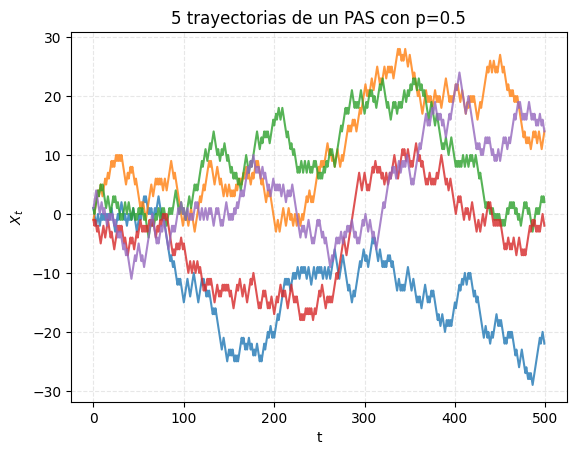

In [13]:
visualizar_PAS_1(0.5,500,5)

Visualización de 5 trayectorias de un PAS con `p=0.6`.

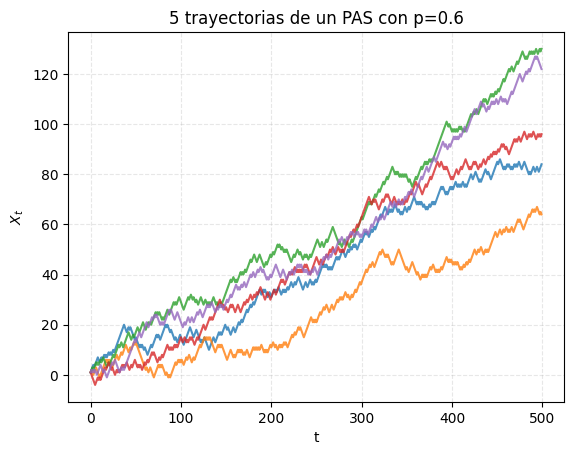

In [5]:
visualizar_PAS_1(0.6,500,5)

Visualización de 5 trayectorias de un PAS con `p=0.4`.

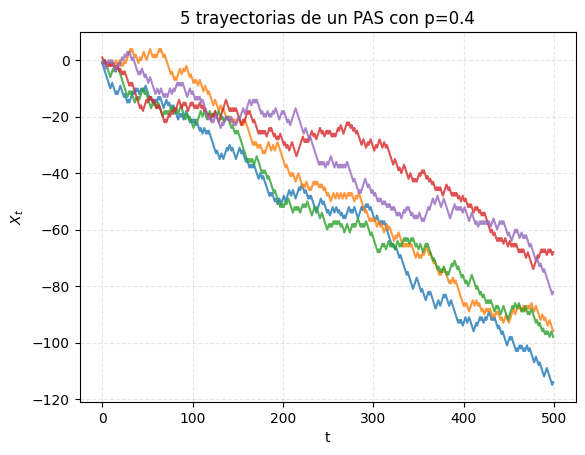

In [6]:
visualizar_PAS_1(0.4,500,5)

# Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)
Ahora creamos una función `visualizar_PAS_2` para visualizar las trayectorias del PAS junto con la media teórica (que en el instante $t$ vale $E[X_t]=(2p−1)t$ ) y un entorno de alrededor de la media de longitud ±1 y ±2 desviaciones típicas teóricas (donde usamos que en el instante $t$ la varianza vale $Var[X_t]=4p(1-p)$ ).

Posteriormente hacemos algunas pruebas para visualizar 20 trayectorias de un PAS variando el parámetro `p`.

In [7]:
def visualizar_PAS_2(p,n,reps=1):

  trayectorias = simular_PAS(p,n,reps) # generamos las trayectorias usando la funcion que creamos al principio
  t = np.arange(1, n+1) # creamos un array con todos los naturales de 1 a n (ponemos n+1 porque el intervalo del arange es abierto por la derecha)
  media_teorica = (2*p-1)*t # calculamos la media teórica
  sigma_teorica = np.sqrt(4*p*(1-p)*t) # calculamos la desviación típica teórica

  plt.plot(trayectorias.T, linewidth=0.6, alpha=0.8) # pintamos las trayectorias (usamos la traspuesta porque Matplotlib interpreta las columnas como conjuntos de datos separados)
  plt.plot(t, media_teorica, linewidth=2, color='black', linestyle='--', label='media_teórica') # pintamos la media teórica
  plt.fill_between(t, media_teorica - 1*sigma_teorica, media_teorica + 1*sigma_teorica, color='gray', alpha=0.4, label='±1σ') # rellenamos un entorno de alrededor de la media de longitud ±1 desviación típica teórica
  plt.fill_between(t, media_teorica - 2*sigma_teorica, media_teorica + 2*sigma_teorica, color='gray', alpha=0.2, label='±2σ') # rellenamos un entorno de alrededor de la media de longitud ±2 desviación típica teórica

  plt.xlabel('t')
  plt.ylabel('$X_t$')
  plt.grid(True, alpha=0.3,linestyle='--') # para pintar la malla del fondo
  plt.title(f"{reps} trayectorias de un PAS con p={p}") # usamos f-string para poner el "titulo" de la gráfica
  plt.legend(loc='upper left')
  plt.show()

  return

Visualización de 20 trayectorias de un PAS con `p=0.5`.

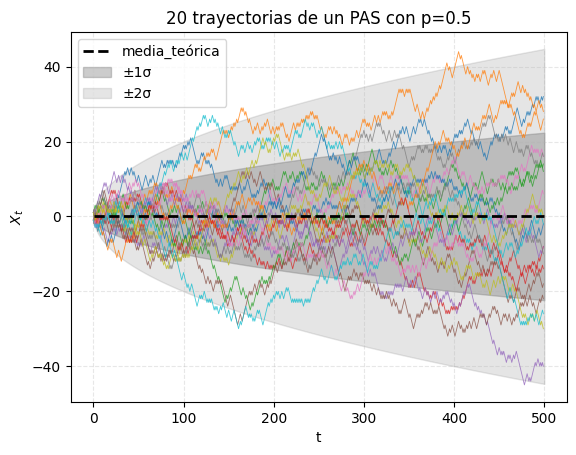

In [8]:
visualizar_PAS_2(0.5,500,20)

Visualización de 20 trayectorias de un PAS con `p=0.75`.

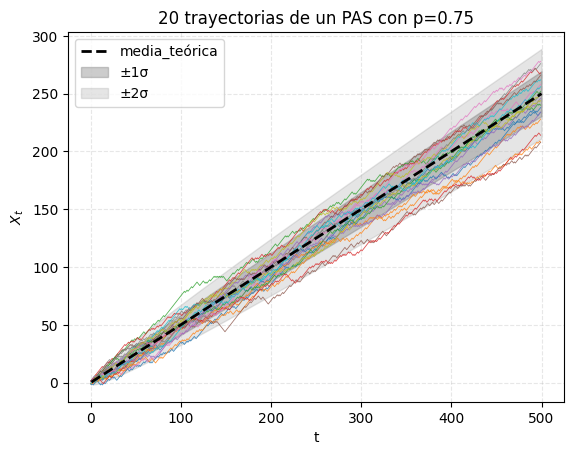

In [9]:
visualizar_PAS_2(0.75,500,20)

Visualización de 20 trayectorias de un PAS con `p=0.95`.

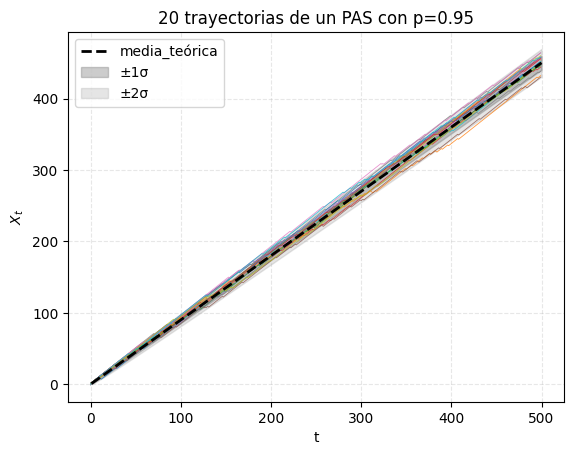

In [10]:
visualizar_PAS_2(0.95,500,20)

# Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)
Finalmente creamos una función `convergencia_
media_empirica` que nos permite visualizar cómo se aproxima la media empírica a la media teórica cuando vamos aumentando el número de trayectorias que promediamos. En este caso vamos a promediar 5, 100, 200, 500 y 1000 trayectorias de un PAS con probabilidad `p`.

In [11]:
def convergencia_media_empirica(p,n):

  t = np.arange(1, n+1) # creamos un array con todos los naturales de 1 a n (ponemos n+1 porque el intervalo del arange es abierto por la derecha)
  trayectorias = simular_PAS(p,n,1000) # creamos las trayectorias
  numero_trayectorias = [5,100,200,500,1000] # vamos a ir aumentando el numero de trayectorias al que calculamos la media empirica para ver como se acerca a la teórica
  colores = ["0.0", "0.2", "0.4", "0.6", "0.8"] # para que pinte las lineas cada vez mas claras a medidad que aumenta el numero de trayectorias

  for i in range(len(numero_trayectorias)):
    media_empirica = np.mean(trayectorias[:numero_trayectorias[i],], axis=0) # calculamos la media empirica de las primeras i trayectorias
    plt.plot(t, media_empirica, color=colores[i], label=f"{numero_trayectorias[i]}") # pintamos la media empirica de i trayectorias

  media_teorica = (2*p-1)*t # calculamos la media teórica
  plt.plot(t, media_teorica, color='red', zorder=1, label='media_teórica') # pintamos la media teórica (zorder=1 es para que salga por detrás de las medias empíricas)

  plt.xlabel('t')
  plt.ylabel('media_empírica')
  plt.grid(True, alpha=0.3,linestyle='--') # para pintar la malla del fondo
  plt.title(f"media teórica y empírica cuando promediamos varias trayectorias")
  plt.legend(loc='best')
  plt.show()

  return

Hacemos una prueba con `p=0.5`

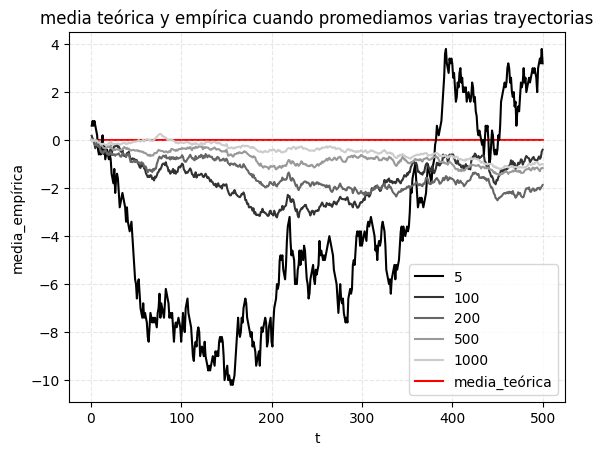

In [22]:
convergencia_media_empirica(0.5,500)
